# Imports

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from stratego_setup_generator.constants import (
    PIECE_TO_STR_FULL, NUM_PIECE_TYPES, PIECE_COUNTS,
    NUM_SETUP_SQUARES, NUM_SETUP_ROWS, NUM_SETUP_COLUMNS
)
from stratego_setup_generator.plotting import create_plot_grid, plot_setup

# Load Data

In [3]:
DATA_PATH = "../data/setups.csv"

data = (
    pd.read_csv(DATA_PATH, header=None)
      .drop_duplicates()
      .reset_index(drop=True)
)

# Square notation

We will use the following square notation.

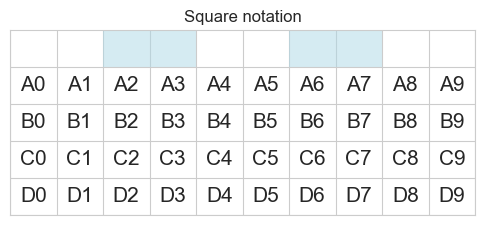

In [4]:
SQUARE_SYMBOLS = dict(
    enumerate([f"{letter}{i}" for letter in "ABCD" for i in range(10)])
)

tile_size = 0.6
fig_size = (NUM_SETUP_COLUMNS * tile_size, NUM_SETUP_ROWS * tile_size)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=fig_size)
plot_setup(range(NUM_SETUP_SQUARES), piece_labels=SQUARE_SYMBOLS, ax=ax)
ax.set_title("Square notation")
plt.show()

# Basic probability definitions

For our analysis we define the following probabilities:
<br>
<br>

- Probability that a piece type will be selected from all pieces (proportional to count).
  <br>
  $$P(\text{piece type}) = \frac{\text{count}(\text{piece type})}{40}$$
  <br>

- Probability that a square will be selected from all squares (uniform over all squares).
  <br>
  $$P(\text{square}) = \frac{1}{40}$$
  <br>

- Given a square, which piece type will be placed there? This probability can be estimated from our data.
  <br>
  $$P(\text{piece type} \mid \text{square}) = \frac{\# \; \text{setups where square is occupied by piece type}}{\# \; \text{setups}}$$
  <br>

- Given a piece type, on which squares is it usually placed? We compute this probability using the Bayes theorem.
  <br>
  $$P(\text{square} \mid \text{piece type}) = \frac{P(\text{piece type} \mid \text{square}) P(\text{square})}{P(\text{piece type})} = \frac{P(\text{piece type} \mid \text{square}) \frac{1}{40}} {\frac{\text{count}(\text{piece type})}{40}} = \frac{P(\text{piece type} \mid \text{square})} {\text{count}(\text{piece type})}$$





In [5]:
# compute P(piece type | square) for all (piece type, square) pairs
# as a dataframe of shape (12, 40)
prob_piece_given_square = data.apply(
    lambda col: (
        col.value_counts(normalize=True)
           .reindex(range(NUM_PIECE_TYPES), fill_value=0.0)
    )
)

# compute P(square | piece type) for all (piece type, square) pairs
# as a dataframe of shape (12, 40)
prob_square_given_piece = (
    prob_piece_given_square.div(pd.Series(PIECE_COUNTS), axis=0)
)

# Association between piece types and squares

We will investigate which pairs of (piece type, square) are strongly tied in human setups using our data.

The measure we will use is lift, defined as:
<br>
$$\text{lift(piece type, square)} = \frac{P(\text{piece type} \mid \text{square})}{P(\text{piece type})}$$
<br>
Lift answers the question "how much more likely is it that a piece type will be placed on a specific square in a human setup, compared to what would be expected by chance?".
It is equal to the probability that a piece type will be placed on a specific square, divided by the probability of the piece type, to account for the fact that piece types with high count are more likely to appear in any square.


In [6]:
# compute lift for all (piece type, square) pairs
# as a dataframe of shape (12, 40)
lift = (
    prob_square_given_piece * NUM_SETUP_SQUARES
).rename(index=PIECE_TO_STR_FULL, columns=SQUARE_SYMBOLS)

# stack and sort
lift_vals_sorted = lift.stack().rename("lift").sort_values(ascending=False)
lift_vals_sorted.index.names=("piece_type", "square")

In [7]:
# top 10
lift_vals_sorted.head(10)

piece_type  square
FLAG        D6        5.962076
            D3        5.366629
            D9        4.814700
SPY         B6        4.505923
            B3        4.220633
FLAG        D0        3.665941
            D7        3.654889
MARSHAL     A6        3.392395
            A3        3.370290
GENERAL     A6        3.281871
Name: lift, dtype: float64

The flag is almost 6 times more likely to be placed on square D6 in a human setup as compared to chance.

In [8]:
# bottom 10
lift_vals_sorted.tail(10)

piece_type  square
SPY         A1        0.030394
            A8        0.030394
FLAG        A4        0.026940
            B4        0.026940
            B5        0.026249
            A8        0.026249
            B8        0.020723
            A5        0.018651
            B1        0.018651
            A1        0.015197
Name: lift, dtype: float64

With a lift of 0.015 the flag is about 66 times less likely to be placed at square A1 in a human setup as compared to chance.

# Common placement of piece types

Where is each piece type usually placed? We use heatmaps to visualise the distribution $P(\text{square} \mid \text{piece type})$ for each piece type.

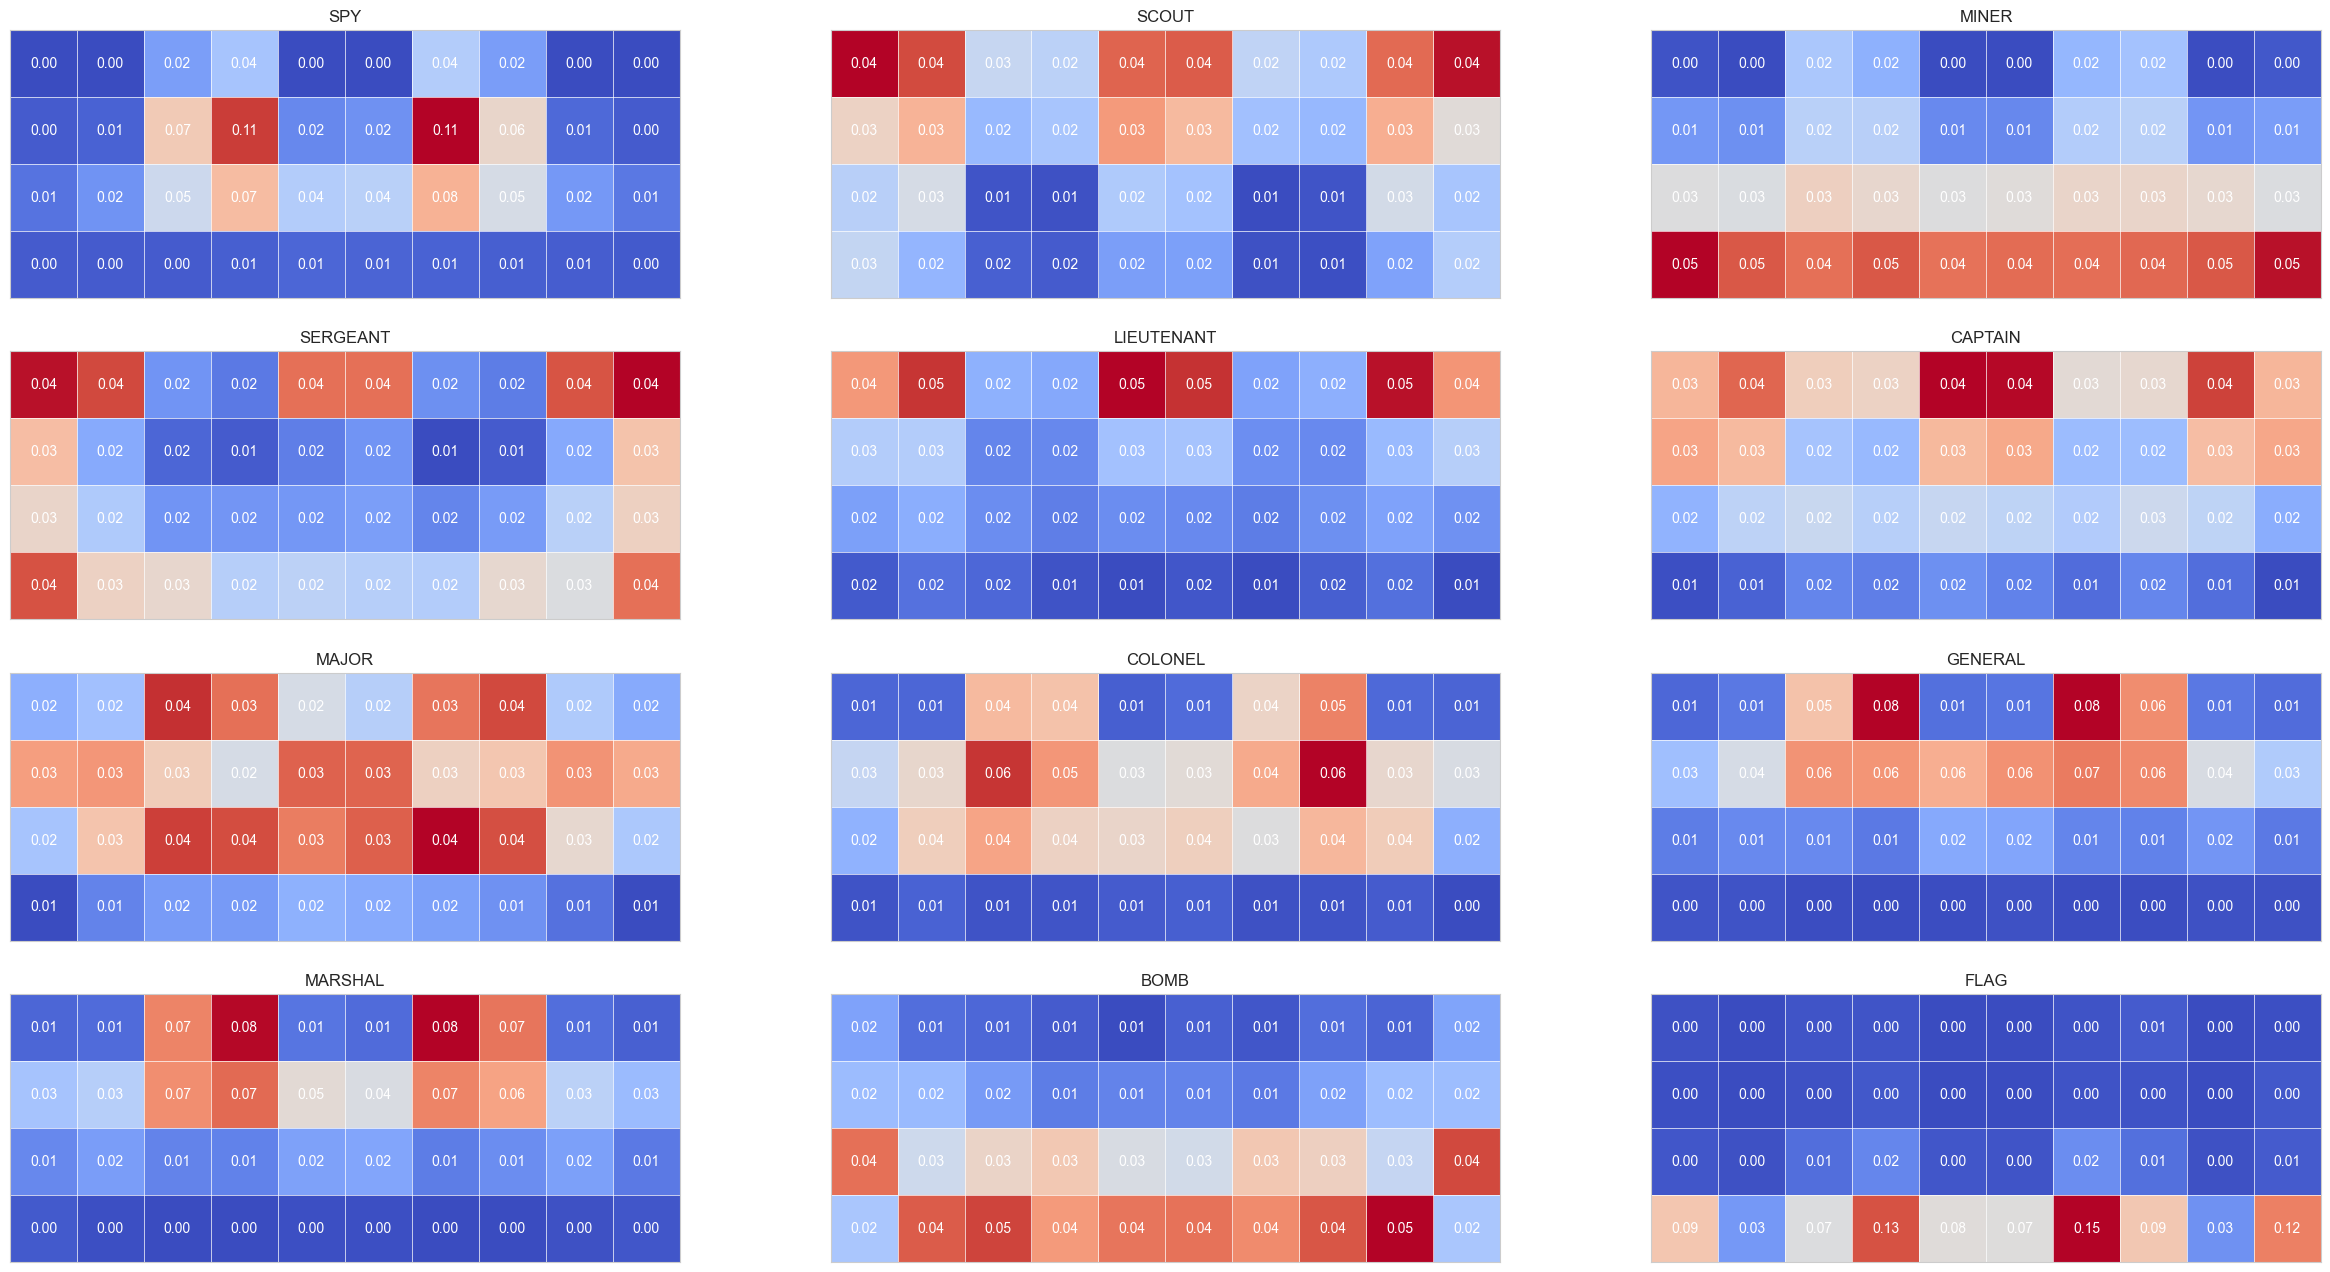

In [9]:
fig, axes = create_plot_grid(
    num_plots=NUM_PIECE_TYPES,
    num_columns=3,
    subplot_width=10,
    subplot_height=4
)
axes = axes.ravel()

for piece in range(NUM_PIECE_TYPES):

    probs = (
        prob_square_given_piece.loc[piece]
                       .to_numpy()
                       .reshape(NUM_SETUP_ROWS, NUM_SETUP_COLUMNS)
    )
    ax = axes[piece]
    ax.imshow(probs, cmap='coolwarm', aspect='equal')
    ax.set_xticks(np.arange(-0.5, probs.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, probs.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(PIECE_TO_STR_FULL[piece])

    for row in range(NUM_SETUP_ROWS):
        for column in range(NUM_SETUP_COLUMNS):
            ax.text(
              column, row, f"{probs[row, column]:.2f}",
              ha='center', va='center', color='white'
            )

plt.show()

# Predictability of placement of each piece type

How predictable is the placement of each piece type? We compute the entropy of $P(\text{square} \mid \text{piece type})$ for each piece type.
<br>
<br>

$$\text{entropy}(\text{piece type}) = -\sum_{\text{square}}{P(\text{square}\mid \text{piece type})} \log{P(\text{square}\mid \text{piece type})}$$

In [10]:
entropy = (
    -prob_square_given_piece * np.log(prob_square_given_piece)
).sum(axis=1)

entropy.rename(index=PIECE_TO_STR_FULL).rename("entropy").sort_values()

FLAG          2.680511
SPY           3.098870
MARSHAL       3.186406
GENERAL       3.186592
COLONEL       3.449640
MINER         3.492210
BOMB          3.571706
LIEUTENANT    3.604294
MAJOR         3.622897
CAPTAIN       3.633831
SERGEANT      3.638704
SCOUT         3.641556
Name: entropy, dtype: float64

The flag has the most predictable placement while the scout has the most unpredictable placement.

# Similarity of placement between piece types

Which piece types have similar placement patterns? We will compute the similarity between the distributions $P(\text{square} \mid \text{piece type})$ for each pair of piece types. As a measure of similarity we will use 1 minus the total variation distance between the distributions, where the total variation distance of two discrete probability distributions $P$ and $Q$ is equal to

$$d_{TV}(P, Q) = \frac{1}{2} \sum_x |P(x) - Q(x)|$$

The similarity measure for the placement of piece type 1 and piece type 2 is thus

$$1 - \frac{1}{2} \sum_{\text{square}} |P(\text{square} \mid \text{piece type 1}) - P(\text{square} \mid \text{piece type 2})|$$

and it is always contained in $[0, 1]$.

In [11]:
# compute a dataframe of pairwise similarities of P(square | piece type)
p = prob_square_given_piece.to_numpy()
pairwise_distr_similarity = pd.DataFrame(
    1.0 - 0.5 * np.abs(p[:, None, :] - p[None, :, :]).sum(axis=-1),
    index=PIECE_TO_STR_FULL.values(),
    columns=PIECE_TO_STR_FULL.values()
)

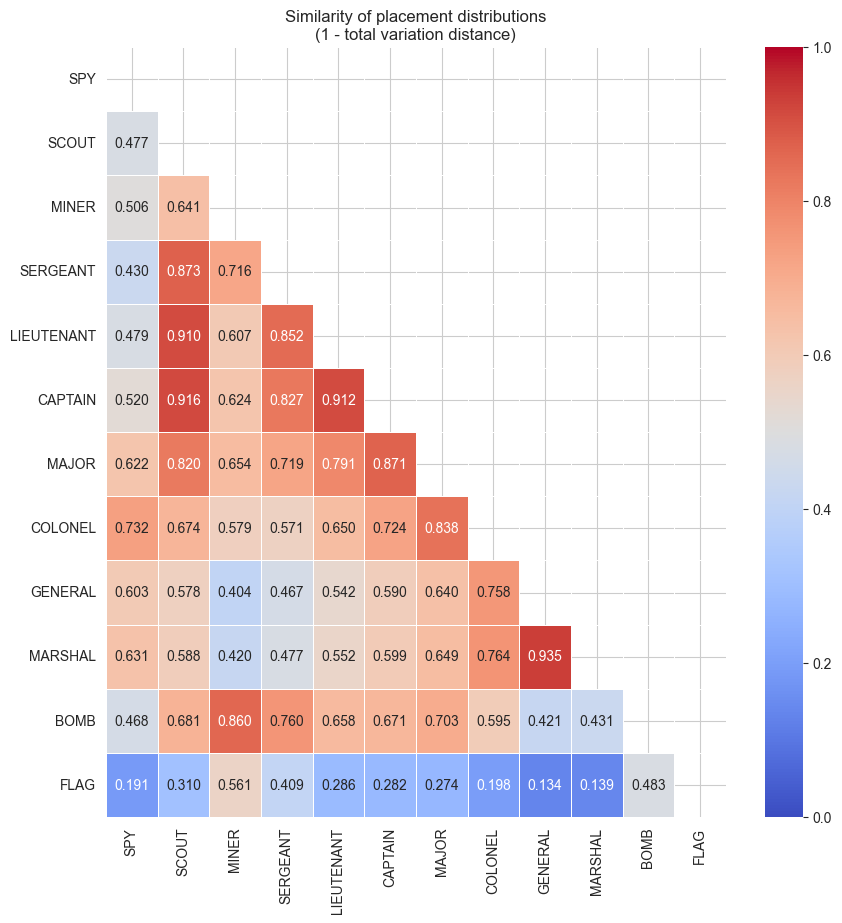

In [12]:
# plot the similarity matrix

plt.figure(figsize=(10, 10))
plt.title(
  "Similarity of placement distributions\n"
  "(1 - total variation distance)"
)
sns.heatmap(
    pairwise_distr_similarity,
    mask=np.triu(np.ones(pairwise_distr_similarity.shape)),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".3f",
    vmin=0.0,
    vmax=1.0,
)
plt.show()

From the similarity matrix we can see that the general and the marshal have the most similar placement patterns while the general and the flag have the most dissimilar.

# More probability definitions

For the rest of the analysis we define some more probabilities:
<br>
<br>

- Probability that if we select two pieces from all pieces without replacement, the first piece will be of type p$_1$ and the second one will be of type p$_2$ (this includes the case p$_1$ = p$_2$).
<br>
$$P(\text{p}_1, \text{p}_2) = {\frac{\text{count}(\text{p}_1)}{40} \cdot \frac{\text{count}(\text{p}_2) - 1_{\{\text{p}_1 = \text{p}_2\}}}{39}}$$
<br>

- Probability of selecting a specific pair of squares s$_1$, s$_2$ out of all possible ordered pairs of squares.
<br>
$$P(\text{s}_1, \text{s}_2) = \frac{1}{40} \cdot \frac{1}{39}$$
<br>

- Given two squares s$_1$ and s$_2$, what is the probability that piece type p$_1$ will occupy s$_1$ and piece type p$_2$ will occupy s$_2$? This probability can be estimated from our data.
  <br>
  $$P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2) = \frac{\# \; \text{setups where s$_1$ is occupied by type p$_1$ and s$_2$ is occupied by type p$_2$}}{\# \; \text{setups}}$$
  <br>
  We define the above probability for all s$_1$, s$_2$ pairs of squares where s$_1$ < s$_2$ ($40 \cdot 39 / 2 = 780$ pairs) and for all p$_1$, p$_2$ pairs of piece types ($12 \cdot 12 = 144$ pairs but flag, spy, marshal and general have a count of 1 so $144 - 4 = 140$ possible pairs). The probabilities can be stored in a $140 \times 780$ dataframe.

- Given piece types p$_1$ and p$_2$, what is the probability that p$_1$ will occupy square s$_1$ and p$_2$ will occupy square s$_2$? We compute this probability using the Bayes theorem.
  <br>
  $$P(\text{s}_1, \text{s}_2 \mid \text{p}_1, \text{p}_2) = \frac{P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2) P(\text{s}_1, \text{s}_2)}{P(\text{p}_1, \text{p}_2)} = \frac{P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2) \frac{1}{40} \frac{1}{39}}{\frac{\text{count}(\text{p}_1)}{40}\frac{\text{count}(\text{p}_2) - 1_{\{\text{p}_1 = \text{p}_2\}}}{39}} = \frac{P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2)} {\text{count}(\text{p}_1) \left(\text{count}(\text{p}_2) - 1_{\{\text{p}_1 = \text{p}_2\}}\right)}$$
  <br>
  We define the above probability for all p$_1$, p$_2$ pairs of piece types where p$_1$ $\leq$ p$_2$ ($12 \cdot 11 / 2 + 12 = 78$ pairs but flag, spy, marshal and general have a count of 1 so $78 - 4 = 74$ possible pairs) and for all s$_1$, s$_2$ pairs of squares ($40 \cdot 39 = 1560$ pairs). The probabilities can be stored in a $74 \times 1560$ dataframe.



# Mutual information between squares

Which pairs of squares are strongly tied, so that knowing which piece type is placed on one of them makes the piece type on the other more predictable? The measure we will use is mutual information, which we compute for two squares s$_1$ and s$_2$ as:
<br>
<br>

$$\text{MI}(\text{s}_1, \text{s}_2) = \sum_{\text{p}_1, \text{p}_2}{P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2)} \log{\frac{P(\text{p}_1, \text{p}_2 \mid \text{s}_1, \text{s}_2)}{P(\text{p}_1 \mid \text{s}_1) P(\text{p}_2 \mid \text{s}_2)}}$$
<br>

We also normalize the mutual information by the minimum of the entropies of $\text{s}_1$ and $\text{s}_2$ so the final measure is:
<br>

$$\text{NMI}(\text{s}_1, \text{s}_2) = \frac{\text{MI}(\text{s}_1, \text{s}_2)}{\min{\{\text{entropy}(\text{s}_1), \text{entropy}(\text{s}_2)\}}}$$

In [13]:
valid_piece_pairs = [
    (p1, p2) for p1, p2 in itertools.product(range(NUM_PIECE_TYPES), repeat=2)
    if p1 != p2 or PIECE_COUNTS[p1] > 1
]

In [14]:
piece_idx = pd.MultiIndex.from_tuples(
    valid_piece_pairs, names=("piece1", "piece2")
)
square_pairs = list(itertools.combinations(range(NUM_SETUP_SQUARES), 2))
square_idx = pd.MultiIndex.from_tuples(
    square_pairs, names=("square1", "square2")
)


joints = []  # store P(p1, p2 | s1, s2) for all s1, s2
prods_of_marginals = []  # store P(p1 | s1) * P(p2 | s2) for all s1, s2
min_entropies = []  # store min{entropy(s1), entropy(s2)} for all s1, s2


for sq_pair in square_pairs:

    sq1, sq2 = sq_pair

    # P(p1, p2 | s1, s2), series of shape (140,)
    joint = (
        data[list(sq_pair)].value_counts(normalize=True)
            .reindex(piece_idx, fill_value=0.0)
            .rename(sq_pair)
    )

    # P(p1 | s1), series of shape (12,)
    sq1_distr = prob_piece_given_square[sq1]

    # P(p2 | s2), series of shape (12,)
    sq2_distr = prob_piece_given_square[sq2]

    # P(p1 | s1) * P(p2 | s2), series of shape (140,)
    piece_idx_level1 = piece_idx.get_level_values(0)
    piece_idx_level2 = piece_idx.get_level_values(1)
    probs_level1 = piece_idx_level1.map(sq1_distr)
    probs_level2 = piece_idx_level2.map(sq2_distr)
    prod_of_marginals = pd.Series(
        probs_level1 * probs_level2, index=piece_idx
    ).rename(sq_pair)

    # min{entropy(s1), entropy(s2)}, scalar
    sq1_entropy = -np.sum(sq1_distr * np.log(sq1_distr))
    sq2_entropy = -np.sum(sq2_distr * np.log(sq2_distr))
    min_entropy = min(sq1_entropy, sq2_entropy)

    joints.append(joint)
    prods_of_marginals.append(prod_of_marginals)
    min_entropies.append(min_entropy)


joints = pd.concat(joints, axis=1)  # dataframe of shape (140, 780)
prods_of_marginals = pd.concat(prods_of_marginals, axis=1)  # dataframe of shape (140, 780)
min_entropies = pd.Series(min_entropies, index=square_idx)  # series of shape (780,)

mutual_info = (
    joints * np.log(joints.where(joints > 0).div(prods_of_marginals))
).sum(axis=0).rename("mutual_info")  # series of shape (780,)

normalized_mutual_info = (
    mutual_info.div(min_entropies)
     .rename("normalized_mutual_info")
     .rename(index=SQUARE_SYMBOLS)
)  # series of shape (780,)

normalized_mutual_info.index.names = ("square1", "square2")

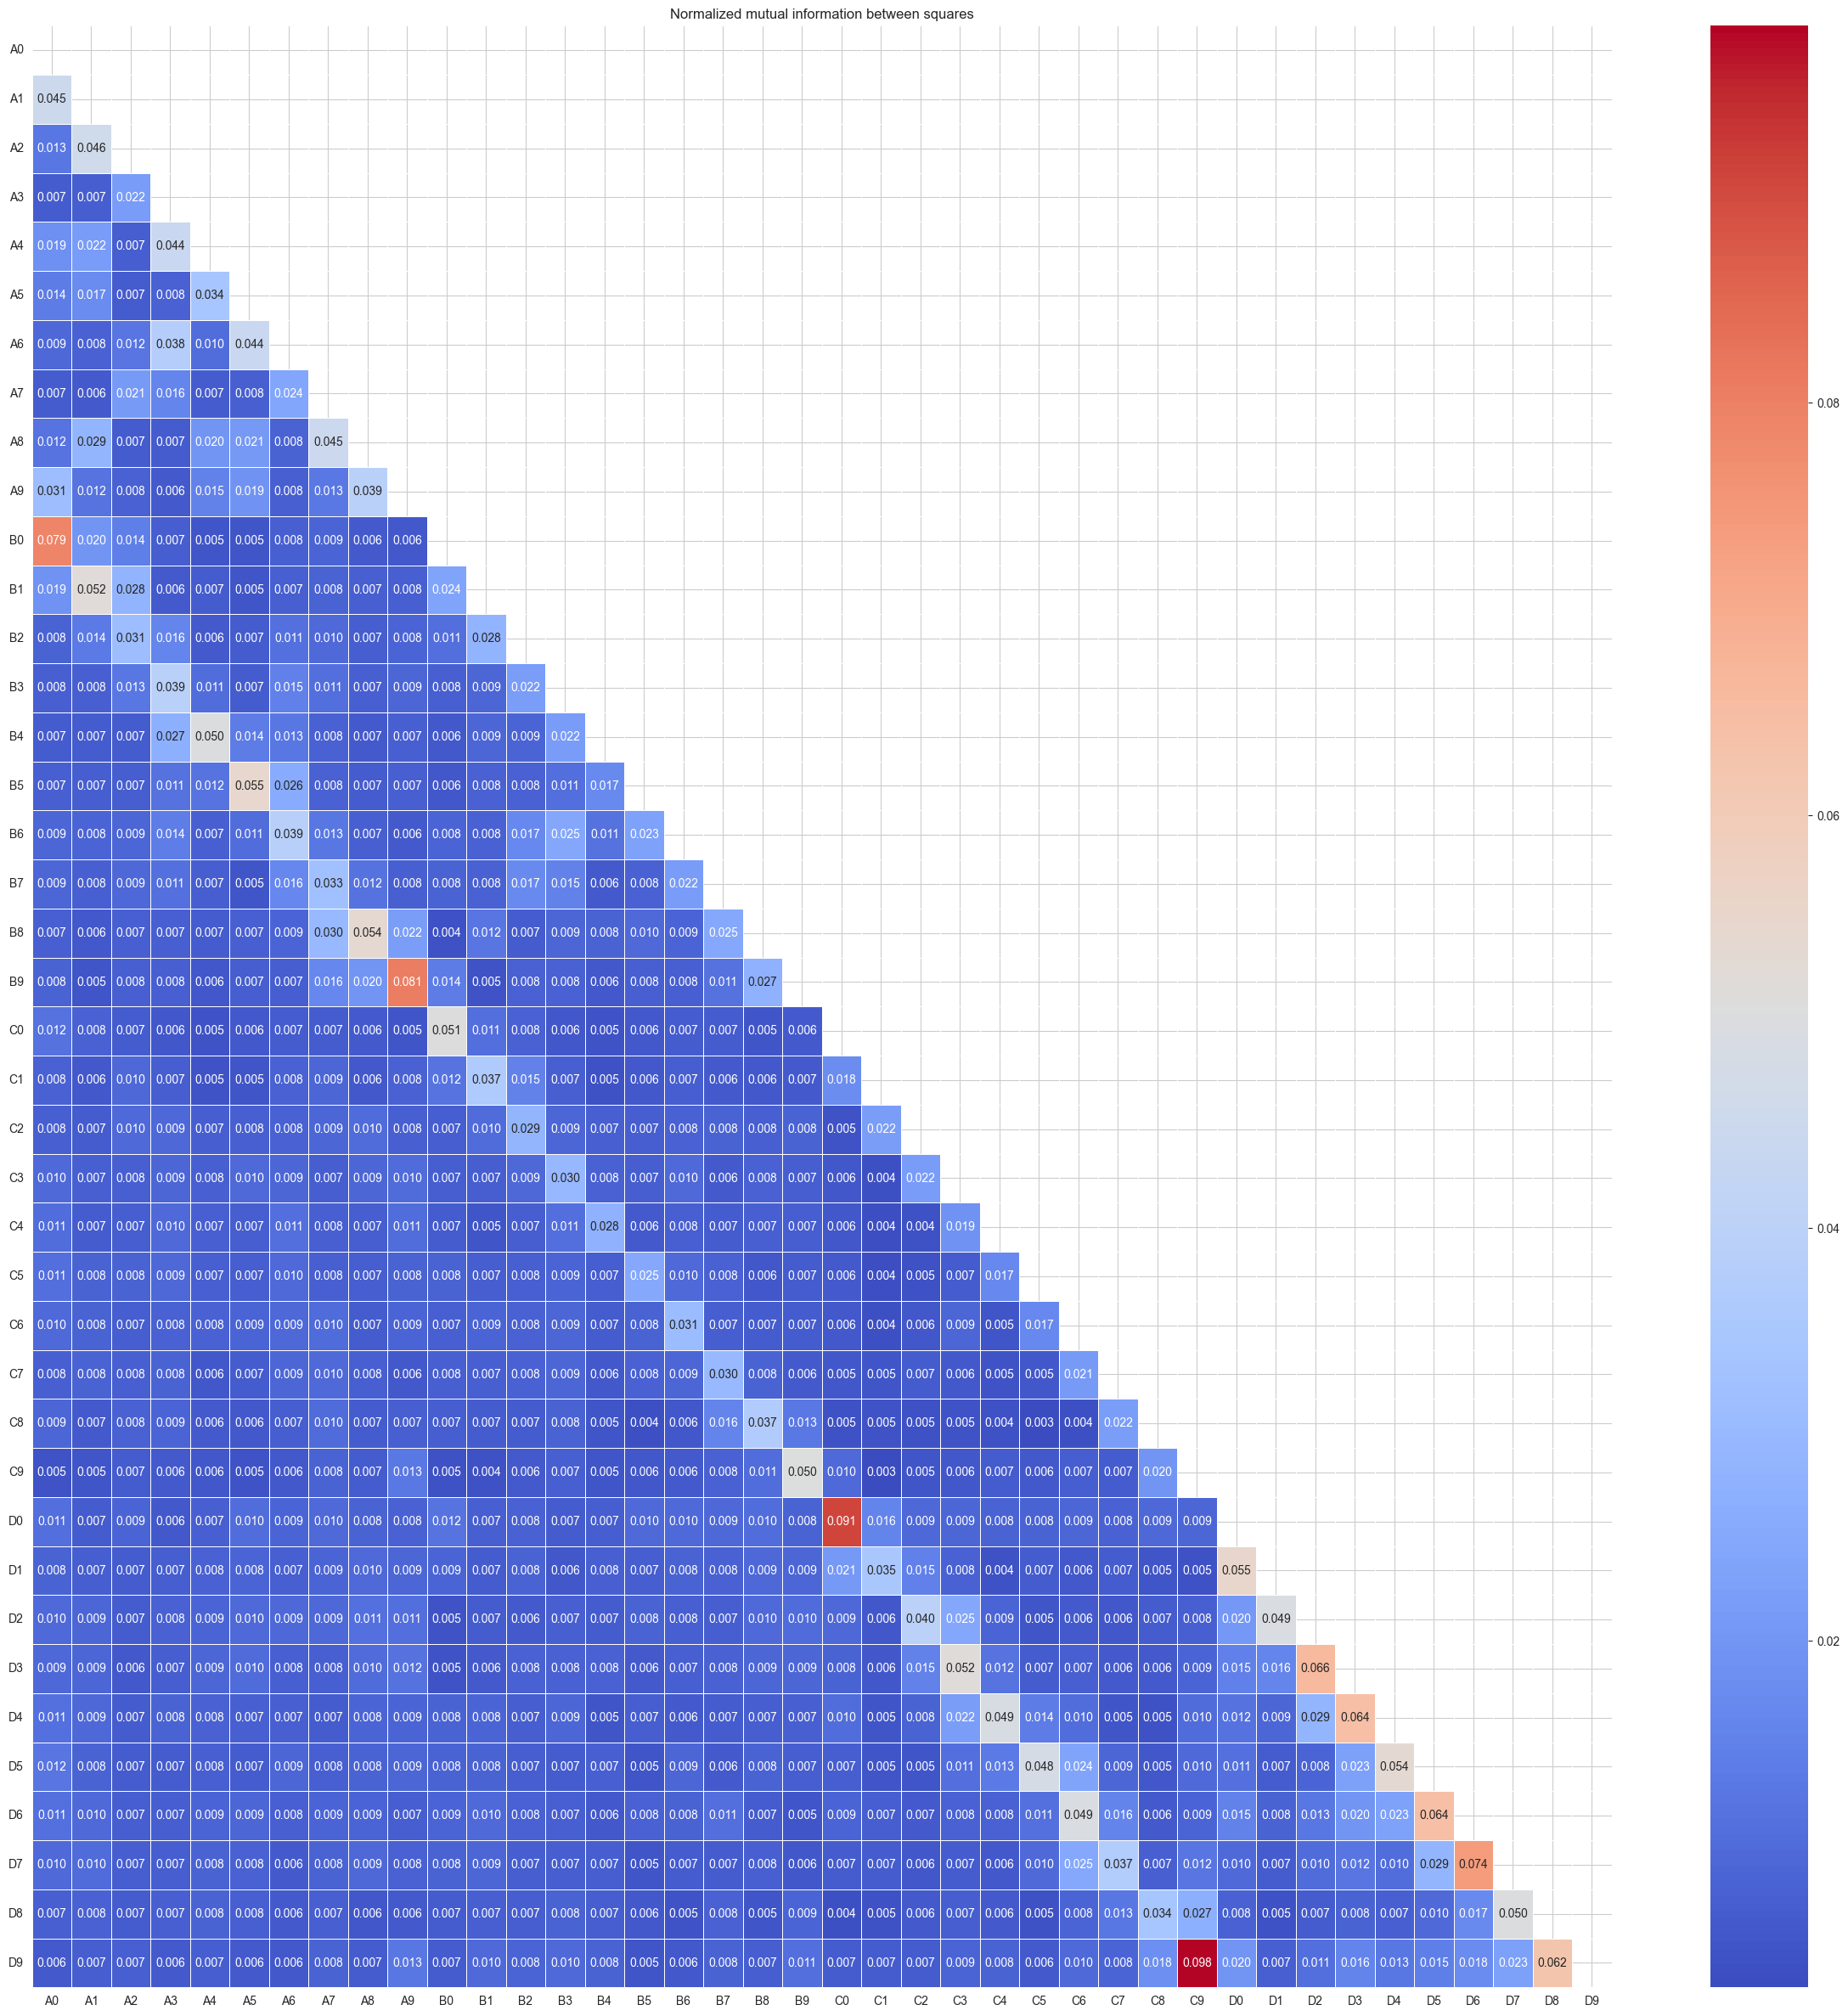

In [15]:
# plot the mutual information matrix

nmi_unstacked = normalized_mutual_info.unstack()
full_nmi_matrix = nmi_unstacked.combine_first(nmi_unstacked.T)

plt.figure(figsize=(30, 30))
plt.title("Normalized mutual information between squares")
sns.heatmap(
    full_nmi_matrix,
    mask=np.triu(np.ones(full_nmi_matrix.shape)),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".3f",
)
plt.yticks(rotation=0)
plt.show()

We observe a higher mutual information for squares that are adjacent to each other on the same row or column (1st and 10th diagonals of the mutual information matrix). The most strongly tied pairs of all are (C9, D9) and (C0, D0).

# Correlation between mutual info and proximity of squares

In addition to plotting the mutual information matrix, we can use scatter plots to visualise the correlation between mutual information and proximity between squares. We will use Manhattan distance to measure the proximity between squares on the board.

In [16]:
def manhattan_dist(sq_pair):
    x1, y1 = divmod(sq_pair[0], NUM_SETUP_COLUMNS)
    x2, y2 = divmod(sq_pair[1], NUM_SETUP_COLUMNS)
    return abs(x1 - x2) + abs(y1 - y2)

distances_manh = pd.Series(
    [manhattan_dist(sq_pair) for sq_pair in square_pairs],
    index=square_idx
).rename("manhattan_distance").rename(index=SQUARE_SYMBOLS)

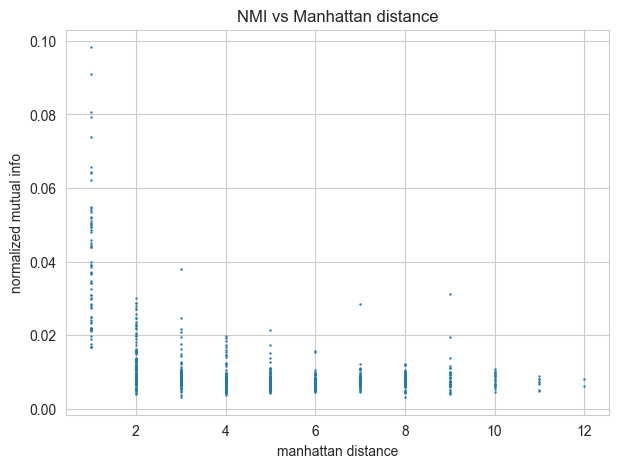

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(distances_manh, normalized_mutual_info, s=0.5)
plt.title("NMI vs Manhattan distance")
plt.xlabel("manhattan distance")
plt.ylabel("normalized mutual info")
plt.show()

We observe some outlier square pairs with high NMI when the Manhattan distance is 3, 7 and 9.

In [18]:
print(normalized_mutual_info.loc[distances_manh == 3].idxmax())
print(normalized_mutual_info.loc[distances_manh == 7].idxmax())
print(normalized_mutual_info.loc[distances_manh == 9].idxmax())

('A3', 'A6')
('A1', 'A8')
('A0', 'A9')


# Mutual information between piece types

In the same way we computed the mutual information between squares, we can compute the mutual information between piece types. This will tell us how much more structured the joint placement of two piece types over square pairs is, compared to when they are put independently on the board, each according to its $P(\text{square} \mid \text{piece type})$ distribution.
<br>

$$\text{MI}(\text{p}_1, \text{p}_2) = \sum_{\text{s}_1, \text{s}_2}{P(\text{s}_1, \text{s}_2 \mid \text{p}_1, \text{p}_2)} \log{\frac{P(\text{s}_1, \text{s}_2 \mid \text{p}_1, \text{p}_2)}{P(\text{s}_1 \mid \text{p}_1) P(\text{s}_2 \mid \text{p}_2)}}$$
<br>

We also normalize by the minimum of the entropies of p$_1$ and p$_2$:
<br>

$$\text{NMI}(\text{p}_1, \text{p}_2) = \frac{\text{MI}(\text{p}_1, \text{p}_2)}{\min{\{\text{entropy}(\text{p}_1), \text{entropy}(\text{p}_2)\}}}$$

In [19]:
valid_piece_combs = [
    pair for pair in valid_piece_pairs if pair[0] <= pair[1]
]
piece_idx = pd.MultiIndex.from_tuples(
    valid_piece_combs, names=("piece1", "piece2")
)

square_ordered_pairs = list(itertools.permutations(range(NUM_SETUP_SQUARES), 2))
square_idx = pd.MultiIndex.from_tuples(
    square_ordered_pairs, names=("square1", "square2")
)


joints = []  # store P(s1, s2 | p1, p2) for all s1, s2
prods_of_marginals = []  # store P(s1 | p1) * P(s2 | p2) for all s1, s2


for sq_pair in square_ordered_pairs:

    sq1, sq2 = sq_pair

    # P(s1, s2 | p1, p2), series of shape (74,)
    joint = (
        data.iloc[:, list(sq_pair)]
            .value_counts(normalize=True)
            .reindex(piece_idx, fill_value=0.0)
            .rename(sq_pair)
    )
    p1 = joint.index.get_level_values(0)
    p2 = joint.index.get_level_values(1)
    denom = pd.Series(
        p1.map(PIECE_COUNTS) * (p2.map(PIECE_COUNTS) - (p1 == p2).astype(int)),
        index=joint.index,
        name=sq_pair
    )
    joint = joint.div(denom)

    # P(s1 | p1), series of shape (12,)
    p1_distr = prob_square_given_piece[sq1]

    # P(s2 | p2), series of shape (12,)
    p2_distr = prob_square_given_piece[sq2]

    # P(s1 | p1) * P(s2 | p2), series of shape (74,)
    piece_idx_level1 = piece_idx.get_level_values(0)
    piece_idx_level2 = piece_idx.get_level_values(1)
    probs_level1 = piece_idx_level1.map(p1_distr)
    probs_level2 = piece_idx_level2.map(p2_distr)
    prod_of_marginals = pd.Series(
        probs_level1 * probs_level2, index=piece_idx
    ).rename(sq_pair)

    joints.append(joint)
    prods_of_marginals.append(prod_of_marginals)


joints = pd.concat(joints, axis=1)  # dataframe of shape (74, 1560)
prods_of_marginals = pd.concat(prods_of_marginals, axis=1)  # dataframe of shape (74, 1560)

min_entropies = pd.Series(
    np.minimum(piece_idx_level1.map(entropy), piece_idx_level2.map(entropy)),
    index=piece_idx
)  # series of shape (74,)

mutual_info = (
    joints * np.log(joints.where(joints > 0).div(prods_of_marginals))
).sum(axis=1).rename("mutual_info")  # series of shape (74,)

normalized_mutual_info = (
    mutual_info.div(min_entropies, axis=0)
      .rename("normalized_mutual_info")
      .rename(index=PIECE_TO_STR_FULL)
)  # series of shape (74,)

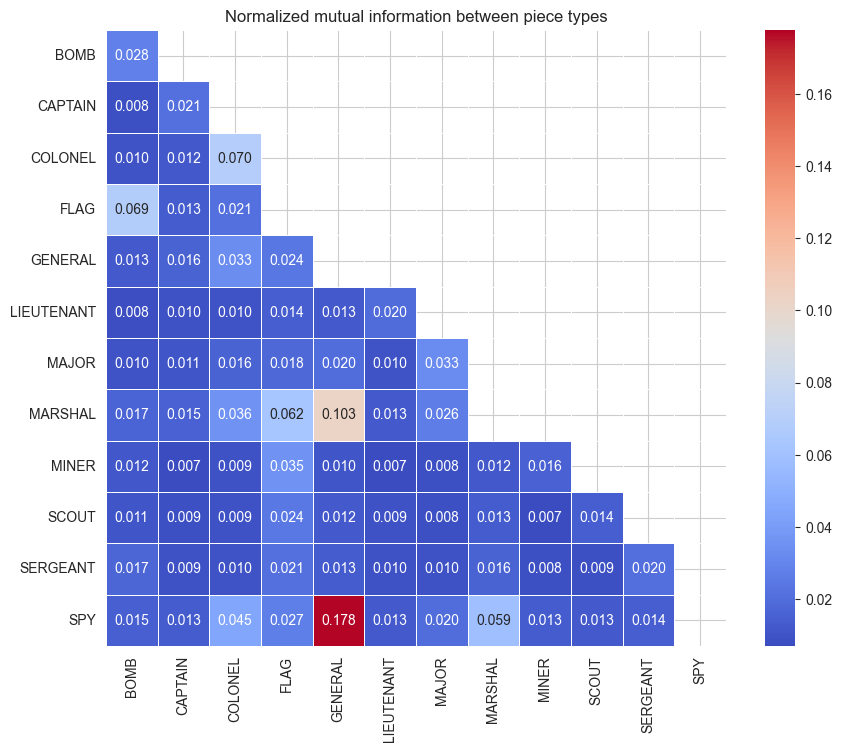

In [20]:
# plot the mutual information matrix

nmi_unstacked = normalized_mutual_info.unstack()
full_nmi_matrix = nmi_unstacked.combine_first(nmi_unstacked.T)

plt.figure(figsize=(10, 8))
plt.title("Normalized mutual information between piece types")
sns.heatmap(
    full_nmi_matrix,
    mask=np.triu(np.ones(full_nmi_matrix.shape), k=1),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".3f",
)
plt.show()

The general and the spy are the most strongly tied piece types.

In [21]:
# top 5
normalized_mutual_info.sort_values(ascending=False).head()

piece1   piece2 
SPY      GENERAL    0.177669
GENERAL  MARSHAL    0.102739
COLONEL  COLONEL    0.069593
BOMB     FLAG       0.068621
MARSHAL  FLAG       0.062416
Name: normalized_mutual_info, dtype: float64